# Hola

En esta notebook se busca maximizar la varianza entre las imagenes cortadas en cuadrantes.

# Loading the DataSet

In [18]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch, numpy as np

In [19]:
painter_to_genre = {
    "Joan": "Surrealismo",
    "Salvador": "Surrealismo",
    "Rene": "Surrealismo",
    "Pablo": "Cubismo",
    "Jackson": "Expresionismo abstracto",
    "Rembrandt": "Barroco",
    "Caravaggio": "Barroco",
    "Camille": "Impresionismo",
    "Alfred": "Impresionismo",
    "Claude": "Impresionismo",
    "Vincent": "Impresionismo",  
}

genre_to_label = {
    "Surrealismo": 0,
    "Cubismo": 1,
    "Expresionismo abstracto": 2,
    "Barroco": 3,
    "Impresionismo": 4,
}

In [20]:
from pathlib import Path
import pandas as pd

root = Path("08 Clasificacion de Movimientos Artisticos/data")

# recoge todos los .jpg (ajusta extensiones si hay .png, etc.)
paths = sorted(root.glob("*.jpg"))

rows = []
for p in paths:
    stem = p.stem  # 'Joan_Miro_001'
    # ejemplo simple: pintor = todo menos la parte final si es número
    painter = stem.split("_")[0]
    genre = painter_to_genre[painter]
    label = genre_to_label[genre]

    rows.append({
        "path": str(p),
        "painter": painter,
        "genre": genre,
        "label": label,
    })

df = pd.DataFrame(rows)

In [21]:
print(df['genre'].value_counts())
df.head()

genre
Impresionismo              75
Surrealismo                50
Barroco                    30
Cubismo                    30
Expresionismo abstracto    15
Name: count, dtype: int64


,path,painter,genre,label
0,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
1,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
2,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
3,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
4,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4


In [22]:
from torch.utils.data import Dataset
from PIL import Image

class PaintingDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        y = int(row["label"])
        if self.transform is not None:
            img = self.transform(img)
        return img, y


# Data Engineering 😜

In [23]:
from torchvision.transforms import functional as F

class QuadrantCrop:
    """
    quadrant ∈ {"ul", "ur", "ll", "lr"}.
    Crops the corresponding quarter of the image.
    """
    def __init__(self, quadrant: str):
        assert quadrant in {"ul", "ur", "ll", "lr"}
        self.quadrant = quadrant

    def __call__(self, img):
        # img is a PIL.Image
        w, h = img.size  # (width, height)

        crop_w = w // 2
        crop_h = h // 2

        if self.quadrant == "ul":
            left, top = 0, 0
        elif self.quadrant == "ur":
            left, top = w - crop_w, 0
        elif self.quadrant == "ll":
            left, top = 0, h - crop_h
        else:  # "lr"
            left, top = w - crop_w, h - crop_h

        return F.crop(img, top, left, crop_h, crop_w)


## Maximizing Variance with ColorJitter

In [24]:
import torch
from PIL import Image

def compute_mean_std_from_df(df, transform):
    channel_sum = torch.zeros(3)
    channel_sq_sum = torch.zeros(3)
    n_pixels = 0

    for path in df["path"]:
        img = Image.open(path).convert("RGB")
        x = transform(img)           # C×H×W, in [0,1]

        B, C, H, W = 1, *x.shape     # fake batch size 1
        n = B * H * W

        channel_sum    += x.view(C, -1).sum(dim=1)
        channel_sq_sum += (x**2).view(C, -1).sum(dim=1)
        n_pixels       += n

    mean = channel_sum / n_pixels
    var  = channel_sq_sum / n_pixels - mean ** 2
    std  = torch.sqrt(var + 1e-8)
    return mean, std

In [8]:
from torchvision import transforms

contrast = np.linspace(0, 10000, 3)
saturation = np.linspace(0, 10000, 3)
brightness = np.linspace(0, 10000, 3)  
hue = np.linspace(0, 0.5, 3)

best_params = {}

for crop in ["ul", "ur", "ll", "lr"]:
    print(f"--- Crop: {crop} ---")
    max_std = -float('inf')
    best_c, best_s, best_b, best_h = None, None, None, None
    for c in contrast:
        for s in saturation:
            for b in brightness:
                for h in hue:
                    stat = transforms.Compose([
                        QuadrantCrop(crop),
                        transforms.Resize((128, 128)),
                        transforms.ColorJitter(contrast=c, saturation=s, brightness=b, hue=h),
                        transforms.ToTensor(),           # -> [0,1]
                    ])

                    mean, std = compute_mean_std_from_df(df, stat)
                    std_norm = torch.norm(std)
                    if std_norm > max_std:
                        max_std = std_norm
                        best_c, best_s, best_b, best_h = c, s, b, h

                    print(f"c={c:.0f}, \t s={s:.0f}, \t b={b:.0f}, \t h={h:.0f}   =>  \t std={std.numpy()}, std_norm={std_norm.item():.4f}")
    best_params[crop] = {'c': best_c, 's': best_s, 'b': best_b, 'h': best_h, 'std_norm': max_std.item()}
    print(f"Best for {crop}: c={best_c}, s={best_s}, b={best_b}, h={best_h}, std_norm={max_std.item()}")

--- Crop: ul ---
c=0, 	 s=0, 	 b=0, 	 h=0   =>  	 std=[0.26328975 0.25782883 0.25852492]
c=0, 	 s=0, 	 b=0, 	 h=0   =>  	 std=[0.25757343 0.2694301  0.25305736]
c=0, 	 s=0, 	 b=0, 	 h=0   =>  	 std=[0.26250267 0.26104164 0.25639647]
c=0, 	 s=0, 	 b=5000, 	 h=0   =>  	 std=[0.05797308 0.0514246  0.05810504]
c=0, 	 s=0, 	 b=5000, 	 h=0   =>  	 std=[0.07739726 0.07732753 0.08076634]
c=0, 	 s=0, 	 b=5000, 	 h=0   =>  	 std=[0.05620283 0.05606798 0.05205589]
c=0, 	 s=0, 	 b=10000, 	 h=0   =>  	 std=[0.05578395 0.04935517 0.05701777]
c=0, 	 s=0, 	 b=10000, 	 h=0   =>  	 std=[0.05295442 0.05133992 0.05826076]
c=0, 	 s=0, 	 b=10000, 	 h=0   =>  	 std=[0.05798952 0.04836645 0.05469141]
c=0, 	 s=5000, 	 b=0, 	 h=0   =>  	 std=[0.46265525 0.47823977 0.44522914]
c=0, 	 s=5000, 	 b=0, 	 h=0   =>  	 std=[0.4531777 0.4598269 0.4603905]
c=0, 	 s=5000, 	 b=0, 	 h=0   =>  	 std=[0.46601218 0.46813965 0.47113115]
c=0, 	 s=5000, 	 b=5000, 	 h=0   =>  	 std=[0.38194132 0.45773005 0.4916112 ]
c=0, 	 s=5000,

In [11]:
print("\nBest parameters for each crop:")
for crop, params in best_params.items():
    print(f"{crop}: {params}")


Best parameters for each crop:
ul: {'c': np.float64(10000.0), 's': np.float64(0.0), 'b': np.float64(0.0), 'h': np.float64(0.0), 'std_norm': 0.8492646217346191}
ur: {'c': np.float64(10000.0), 's': np.float64(0.0), 'b': np.float64(0.0), 'h': np.float64(0.0), 'std_norm': 0.8492080569267273}
ll: {'c': np.float64(10000.0), 's': np.float64(5000.0), 'b': np.float64(0.0), 'h': np.float64(0.5), 'std_norm': 0.8459563851356506}
lr: {'c': np.float64(10000.0), 's': np.float64(0.0), 'b': np.float64(0.0), 'h': np.float64(0.5), 'std_norm': 0.8433293104171753}


In [ ]:
# save the best_params dictionary to a file
import json
with open('08 Clasificacion de Movimientos Artisticos/info/best_params.json', 'w') as f:
    json.dump(best_params, f, indent=4)

In [15]:
import json
with open('08 Clasificacion de Movimientos Artisticos/info/best_params.json', 'r') as f:
    best_params = json.load(f)

In [ ]:
from torchvision import transforms


# stat means and std transforms with best parameters
stat_ul = transforms.Compose([
    QuadrantCrop("ul"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=best_params['ul']['c'], saturation=best_params['ul']['s'], brightness=best_params['ul']['b'], hue=best_params['ul']['h']),
    transforms.ToTensor(),
])

stat_ur = transforms.Compose([
    QuadrantCrop("ur"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=best_params['ur']['c'], saturation=best_params['ur']['s'], brightness=best_params['ur']['b'], hue=best_params['ur']['h']),
    transforms.ToTensor(),
])

stat_ll = transforms.Compose([
    QuadrantCrop("ll"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=best_params['ll']['c'], saturation=best_params['ll']['s'], brightness=best_params['ll']['b'], hue=best_params['ll']['h']),
    transforms.ToTensor(),
])

stat_lr = transforms.Compose([
    QuadrantCrop("lr"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=best_params['lr']['c'], saturation=best_params['lr']['s'], brightness=best_params['lr']['b'], hue=best_params['lr']['h']),
    transforms.ToTensor(),
])

## Get Mean and Std ef each cuadrant

In [26]:
# stat_ul, stat_ur, stat_ll, stat_lr defined as before (QuadrantCrop + Resize + ToTensor)
mean_ul, std_ul = compute_mean_std_from_df(df, stat_ul)
mean_ur, std_ur = compute_mean_std_from_df(df, stat_ur)
mean_ll, std_ll = compute_mean_std_from_df(df, stat_ll)
mean_lr, std_lr = compute_mean_std_from_df(df, stat_lr)

print("UL:", mean_ul, std_ul)
print("UR:", mean_ur, std_ur)
print("LL:", mean_ll, std_ll)
print("LR:", mean_lr, std_lr)


UL: tensor([0.5556, 0.4757, 0.3624]) tensor([0.4950, 0.4971, 0.4790])
UR: tensor([0.5748, 0.4862, 0.3693]) tensor([0.4926, 0.4976, 0.4810])
LL: tensor([0.4798, 0.4697, 0.4716]) tensor([0.4848, 0.4871, 0.4867])
LR: tensor([0.4587, 0.4498, 0.4295]) tensor([0.4830, 0.4857, 0.4839])


Results no color jittering
```bash
UL: tensor([0.5137, 0.4741, 0.4183]) tensor([0.2633, 0.2578, 0.2585])
UR: tensor([0.5185, 0.4773, 0.4243]) tensor([0.2598, 0.2562, 0.2641])
LL: tensor([0.4776, 0.4220, 0.3525]) tensor([0.2496, 0.2390, 0.2269])
LR: tensor([0.4764, 0.4229, 0.3585]) tensor([0.2504, 0.2425, 0.2359])
```

Results with color jittering `contrast=1.5, saturation=1.5`
```bash
UL: tensor([0.5165, 0.4690, 0.4055]) tensor([0.3070, 0.2975, 0.3078])
UR: tensor([0.5172, 0.4707, 0.4255]) tensor([0.2931, 0.2896, 0.3039])
LL: tensor([0.4834, 0.4192, 0.3336]) tensor([0.2983, 0.2766, 0.2674])
LR: tensor([0.4832, 0.4193, 0.3363]) tensor([0.3066, 0.2873, 0.2882])
```

In [ ]:
# save mean_ul, std_ul, mean_ur, std_ur, mean_ll, std_ll, mean_lr, std_lr to json
mean_std = {
    "mean_ul": mean_ul.tolist(),
    "std_ul": std_ul.tolist(),
    "mean_ur": mean_ur.tolist(),
    "std_ur": std_ur.tolist(),
    "mean_ll": mean_ll.tolist(),
    "std_ll": std_ll.tolist(),
    "mean_lr": mean_lr.tolist(),
    "std_lr": std_lr.tolist(),
}

# save to file
import json
with open('08 Clasificacion de Movimientos Artisticos/info/mean_std.json', 'w') as f:
    json.dump(mean_std, f, indent=4)

In [ ]:
# read mean_ul, std_ul, mean_ur, std_ur, mean_ll, std_ll, mean_lr, std_lr from json
import json
with open('08 Clasificacion de Movimientos Artisticos/info/mean_std.json', 'r') as f:
    mean_std = json.load(f)

# convert to numpy arrays
mean_ul = np.array(mean_std["mean_ul"])
std_ul = np.array(mean_std["std_ul"])
mean_ur = np.array(mean_std["mean_ur"])
std_ur = np.array(mean_std["std_ur"])
mean_ll = np.array(mean_std["mean_ll"])
std_ll = np.array(mean_std["std_ll"])
mean_lr = np.array(mean_std["mean_lr"])
std_lr = np.array(mean_std["std_lr"])

In [29]:
transf_ul = transforms.Compose([
    QuadrantCrop("ul"),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ul.tolist(), std=std_ul.tolist()),
])

transf_ur = transforms.Compose([
    QuadrantCrop("ur"),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ur.tolist(), std=std_ur.tolist()),
])

transf_ll = transforms.Compose([
    QuadrantCrop("ll"),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ll.tolist(), std=std_ll.tolist()),
])

transf_lr = transforms.Compose([
    QuadrantCrop("lr"),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_lr.tolist(), std=std_lr.tolist()),
])


# Visualización de imágenes con los mejores parámetros encontrados

In [58]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=863)

In [85]:
train_ul = PaintingDataset(train_df, transform=transf_ul)
train_ur = PaintingDataset(train_df, transform=stat_ur)
train_ll = PaintingDataset(train_df, transform=stat_ll)
train_lr = PaintingDataset(train_df, transform=stat_lr)

import torch.utils.data
train_ds = torch.utils.data.ConcatDataset([train_ul, train_ur, train_ll, train_lr])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1223118..0.65212774].


Label: 4 Impresionismo


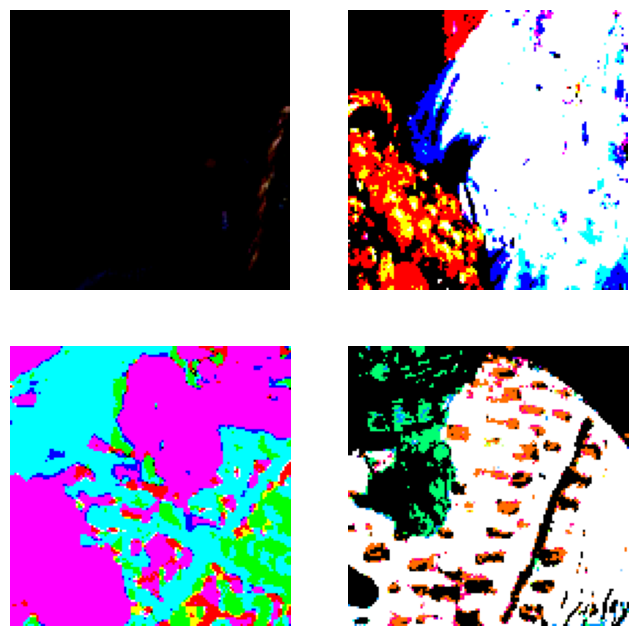

In [96]:
import random
r = random.randint(0, len(train_ul)-1)
img_ul, y = train_ul[r]
img_ur, y = train_ur[r]
img_ll, y = train_ll[r]
img_lr, y = train_lr[r]

print("Label:", y, train_df.iloc[r]["genre"])


import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0,0].imshow((img_ul).permute(1,2,0).cpu().numpy())
axes[0,0].axis("off")

axes[0,1].imshow((img_ur).permute(1,2,0).cpu().numpy())
axes[0,1].axis("off")

axes[1,0].imshow((img_ll).permute(1,2,0).cpu().numpy())
axes[1,0].axis("off")

axes[1,1].imshow((img_lr).permute(1,2,0).cpu().numpy())
axes[1,1].axis("off")

plt.show()
